ESERCIZIO
Partendo dal modello della lezione

Aggiornamento pipeline

Obbiettivo
L'obbiettivo di questo esercizio è migliorare il feedback visimo del modello sulla nostra immagine Task
Potenziamo il modello: modifichiamo lo script per mostrare sopra il riquadro il nome della classe più probabile per l'oggetto individuato
Analisi della 'Nuvola': abbassa la soglia di confidenza dei candidati da 0.1 a 0.05 nel metodo perform_analysis
Osservazione: esegui lo script sull'immagine di test precedente

c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Caricamento modello YOLOv8: yolo_v8_m_pascalvoc...
Scaricamento immagine da: https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg
Esecuzione inferenza del modello in corso...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Disegno di 3 riquadri con etichette oggetto...
Analisi completata! Risultato salvato in: 'risultato_yolo_completo.png'


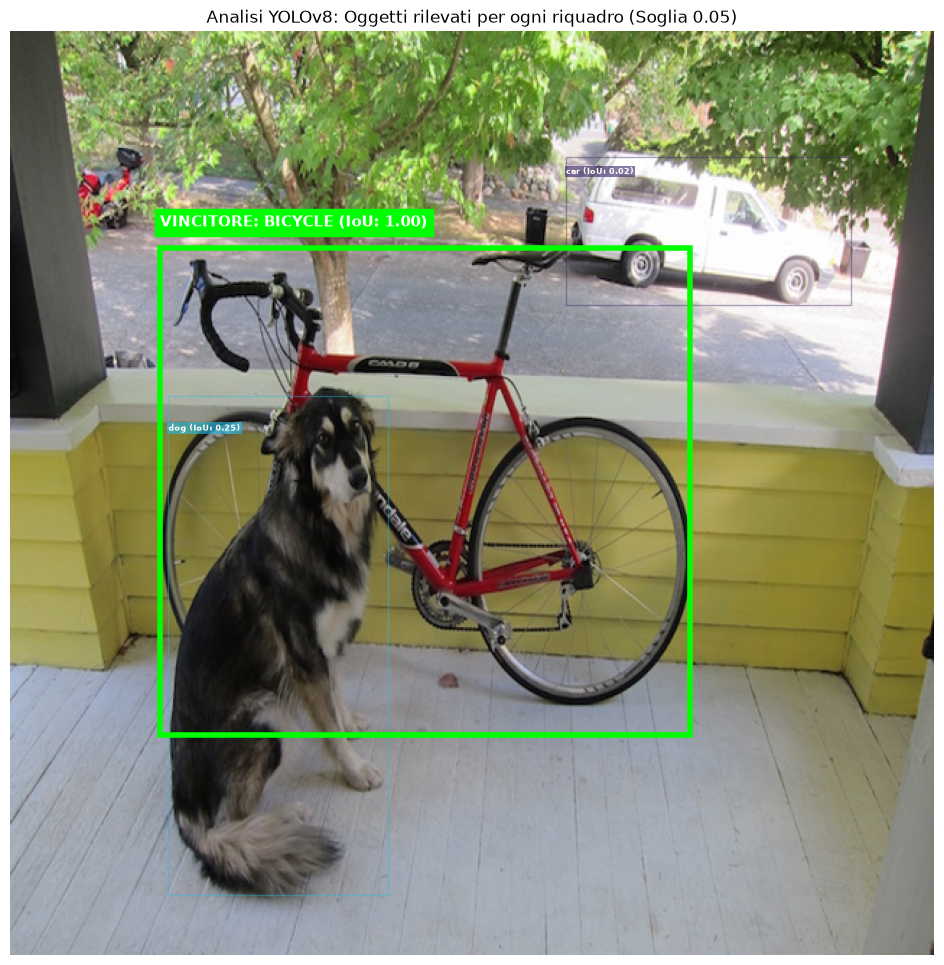

In [1]:
import os

# --- CONFIGURAZIONE BACKEND ---
# Keras 3 può usare diversi motori. Forziamo TensorFlow perché è il più 
# stabile per caricare i modelli YOLO pre-addestrati in KerasCV ed evitare errori di forma.
os.environ["KERAS_BACKEND"] = "tensorflow" 

import keras
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO

class YOLONMSVisualizer:
    """
    Questa classe gestisce il caricamento di un modello YOLOv8 e la 
    visualizzazione dell'analisi IoU (Intersection over Union).
    """

    def __init__(self, model_preset="yolo_v8_m_pascalvoc"):
        """
        Inizializza il rilevatore YOLO.
        NOTA: Utilizziamo il preset 'm_pascalvoc' perché è l'unico verificato 
        nel tuo ambiente. Abbiamo aggiunto il mapping dei nomi delle classi.
        """
        print(f"Caricamento modello YOLOv8: {model_preset}...")
        
        # Carichiamo il rilevatore pre-addestrato. 
        self.model = keras_cv.models.YOLOV8Detector.from_preset(
            model_preset,
            bounding_box_format="xyxy",
        )
        
        # Mapping delle classi per Pascal VOC (per rendere l'analisi superiore)
        self.class_mapping = {
            0: "aeroplane", 1: "bicycle", 2: "bird", 3: "boat", 4: "bottle",
            5: "bus", 6: "car", 7: "cat", 8: "chair", 9: "cow",
            10: "diningtable", 11: "dog", 12: "horse", 13: "motorbike",
            14: "person", 15: "pottedplant", 16: "sheep", 17: "sofa",
            18: "train", 19: "tvmonitor"
        }

    def calculate_iou(self, box1, box2):
        """
        Calcola matematicamente l'IoU tra due rettangoli.
        L'IoU (0.0 a 1.0) indica quanto i box sono sovrapposti.
        """
        x_left = max(box1[0], box2[0])
        y_top = max(box1[1], box2[1])
        x_right = min(box1[2], box2[2])
        y_bottom = min(box1[3], box2[3])

        if x_right <= x_left or y_bottom <= y_top:
            return 0.0

        intersection_area = (x_right - x_left) * (y_bottom - y_top)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        
        union_area = area1 + area2 - intersection_area
        return intersection_area / union_area

    def load_image(self, url):
        """Scarica l'immagine dal web e la ridimensiona per YOLO (640x640)."""
        print(f"Scaricamento immagine da: {url}")
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        
        img = Image.open(BytesIO(response.content)).convert("RGB")
        return np.array(img.resize((640, 640)))

    def perform_analysis(self, image_url):
        """Esegue l'inferenza del modello e prepara la visualizzazione."""
        image = self.load_image(image_url)
        input_data = np.expand_dims(image, axis=0) 
        
        print("Esecuzione inferenza del modello in corso...")
        output = self.model.predict(input_data)
        
        # Estraiamo i box, i punteggi e gli ID delle classi
        boxes = output['boxes'][0]
        confs = output['confidence'][0]
        classes = output['classes'][0]
        
        # SOGLIA ESERCIZIO: 0.05 per analizzare la "nuvola"
        mask = confs > 0.05
        candidates = boxes[mask]
        candidate_classes = classes[mask] # ID classi per i candidati
        
        if len(boxes) > 0:
            # Recuperiamo l'etichetta del vincitore principale
            winner_class_id = int(classes[0])
            winner_label = self.class_mapping.get(winner_class_id, f"ID: {winner_class_id}")
            
            self.plot_results(image, candidates, candidate_classes, boxes[0], winner_label)
        else:
            print("Nessun oggetto rilevato dal modello.")

    def plot_results(self, image, candidates, candidate_classes, final_box, winner_label):
        """Genera il grafico finale con etichette per ogni riquadro rilevato."""
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(image)
        
        # Mappa colori 'turbo' ad alto contrasto
        cmap = plt.colormaps.get_cmap('turbo')

        print(f"Disegno di {len(candidates)} riquadri con etichette oggetto...")
        for i, (box, class_id) in enumerate(zip(candidates, candidate_classes)):
            score = self.calculate_iou(box, final_box)
            
            # Saltiamo il disegno se è il vincitore (lo gestiamo dopo separatamente)
            if score > 0.999: continue

            # Determiniamo il nome dell'oggetto per questo riquadro
            obj_name = self.class_mapping.get(int(class_id), f"ID: {int(class_id)}")
            color = cmap(score)
            
            # Rettangolo del candidato
            rect = patches.Rectangle(
                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                linewidth=1, edgecolor=color, facecolor='none', alpha=0.4
            )
            ax.add_patch(rect)
            
            # Etichetta: Mostra OGGETTO + IoU
            if score > 0.02:
                label_text = f"{obj_name} (IoU: {score:.2f})"
                ax.text(box[0], box[1] + (i % 10) * 12, label_text, color='white',
                        fontsize=6, fontweight='bold', 
                        bbox=dict(facecolor=color, alpha=0.6, edgecolor='none', pad=1))

        # DISEGNO DEL VINCITORE (PREDIZIONE FINALE DOPO NMS)
        f_rect = patches.Rectangle(
            (final_box[0], final_box[1]), final_box[2]-final_box[0], 
            final_box[3]-final_box[1], linewidth=4, 
            edgecolor='#00FF00', facecolor='none', zorder=10
        )
        ax.add_patch(f_rect)
        
        # Etichetta superiore per l'oggetto vincitore
        ax.text(final_box[0], final_box[1]-15, f"VINCITORE: {winner_label.upper()} (IoU: 1.00)", 
                color='white', fontsize=11, fontweight='bold', 
                backgroundcolor='#00FF00', zorder=11)

        plt.title(f"Analisi YOLOv8: Oggetti rilevati per ogni riquadro (Soglia 0.05)")
        plt.axis('off') 
        
        output_file = "risultato_yolo_completo.png"
        plt.savefig(output_file, bbox_inches='tight')
        print(f"Analisi completata! Risultato salvato in: '{output_file}'")
        plt.show()

# --- BLOCCO DI ESECUZIONE ---
if __name__ == "__main__":
    URL_TEST = "https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg"
    
    vis = YOLONMSVisualizer()
    vis.perform_analysis(URL_TEST)